        # 유튜브 분야 트렌드 예측 프로젝트

        본 노트북은 프로젝트 전 과정을 다음 순서로 정리한다.

        1. 데이터 수집 및 구성
        2. 데이터 정리 및 변수 구성
        3. 탐색적 데이터 분석(EDA)
        4. 모델 비교 실험
        5. 최종 예측 결과

        최종 목표는 **과거 추세 데이터와 최근 시계열 반응을 결합하여, 6월 및 하반기(Q3, Q4)에 상승 가능성이 높은 유튜브 분야를 예측하는 것**이다.
        


In [1]:
        import json
        from pathlib import Path

        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from IPython.display import Image, Markdown, display

        import paper_visualizations as pv
        import paper_model_experiments as pme

        plt.rcParams['font.family'] = 'Malgun Gothic'
        plt.rcParams['axes.unicode_minus'] = False

        ROOT = Path(r"C:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex")
        DATA_DIR = ROOT / "project_ready_data"
        MODEL_DIR = DATA_DIR / "model_outputs"
        FIG_DIR = DATA_DIR / "paper_figures"

        READY_SUMMARY_PATH = DATA_DIR / "ready_data_summary.json"
        READY_VIDEO_PATH = DATA_DIR / "ready_video_pool_dedup.csv"
        READY_MAIN_PATH = DATA_DIR / "ready_main_model_table.csv"
        READY_WEEKLY_PATH = DATA_DIR / "ready_category_weekly_trend.csv"
        READY_TS_PATH = DATA_DIR / "ready_timeseries_support.csv"
        READY_TS_READINESS_PATH = DATA_DIR / "ready_timeseries_readiness.csv"
        HIST_PATH = ROOT / "youtube_category_output_expanded_fast" / "historical_2020_2025" / "historical_2020_2025_latest.csv"

        DIRECTION_SUMMARY_PATH = MODEL_DIR / "direction_classification_summary.json"
        QUARTERLY_SUMMARY_PATH = MODEL_DIR / "quarterly_direct_forecast_summary.json"
        VIDEO_LEVEL_SUMMARY_PATH = MODEL_DIR / "video_level_model_summary.json"
        PAPER_MONTHLY_COMPARISON_PATH = MODEL_DIR / "paper_monthly_model_comparison.csv"
        PAPER_MONTHLY_SUMMARY_PATH = MODEL_DIR / "paper_monthly_model_comparison_summary.json"
        PAPER_MONTHLY_RANKING_PATH = MODEL_DIR / "paper_monthly_ranking_comparison.csv"
        PAPER_MONTHLY_RANKING_SUMMARY_PATH = MODEL_DIR / "paper_monthly_ranking_comparison_summary.json"
        


In [2]:
        ready_summary = json.loads(READY_SUMMARY_PATH.read_text(encoding='utf-8-sig'))
        direction_summary = json.loads(DIRECTION_SUMMARY_PATH.read_text(encoding='utf-8-sig'))
        quarterly_summary = json.loads(QUARTERLY_SUMMARY_PATH.read_text(encoding='utf-8-sig'))
        video_level_summary = json.loads(VIDEO_LEVEL_SUMMARY_PATH.read_text(encoding='utf-8-sig'))

        video_df = pd.read_csv(READY_VIDEO_PATH)
        main_df = pd.read_csv(READY_MAIN_PATH)
        weekly_df = pd.read_csv(READY_WEEKLY_PATH)
        ts_df = pd.read_csv(READY_TS_PATH)
        readiness = pd.read_csv(READY_TS_READINESS_PATH)
        historical_rows = sum(1 for _ in HIST_PATH.open(encoding='utf-8')) - 1

        summary_df = pd.DataFrame({
            '항목': ['전체 통합 영상', '중복 제거 영상', '과거 데이터', '시계열 데이터', '메인 학습 행', '멀티모달 학습 행'],
            '값': [
                ready_summary['video_pool_all_rows'],
                ready_summary['video_pool_dedup_rows'],
                historical_rows,
                ready_summary['timeseries_rows'],
                ready_summary['main_model_ready_rows'],
                ready_summary['multimodal_training_rows'],
            ]
        })
        display(summary_df)
        


,항목,값
0,전체 통합 영상,18958
1,중복 제거 영상,16641
2,과거 데이터,2786
3,시계열 데이터,5770
4,메인 학습 행,1727
5,멀티모달 학습 행,5884


        ## 1. 데이터 수집 및 구성

        본 프로젝트는 **과거 추세 데이터(2020~2025)** 와 **최근 시계열 반응 데이터(2026.04~05)** 를 함께 사용한다.

        - 과거 데이터는 분야별 장기 흐름과 계절성, 기본 체력을 반영한다.
        - 최근 시계열 데이터는 초기 반응 속도와 모멘텀을 반영한다.
        - 최종적으로 영상 단위 데이터와 분야-주차 단위 데이터를 모두 활용할 수 있는 구조로 통합하였다.
        


C:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\paper_visualizations.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.885])


Saved figures to: C:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\project_ready_data\paper_figures


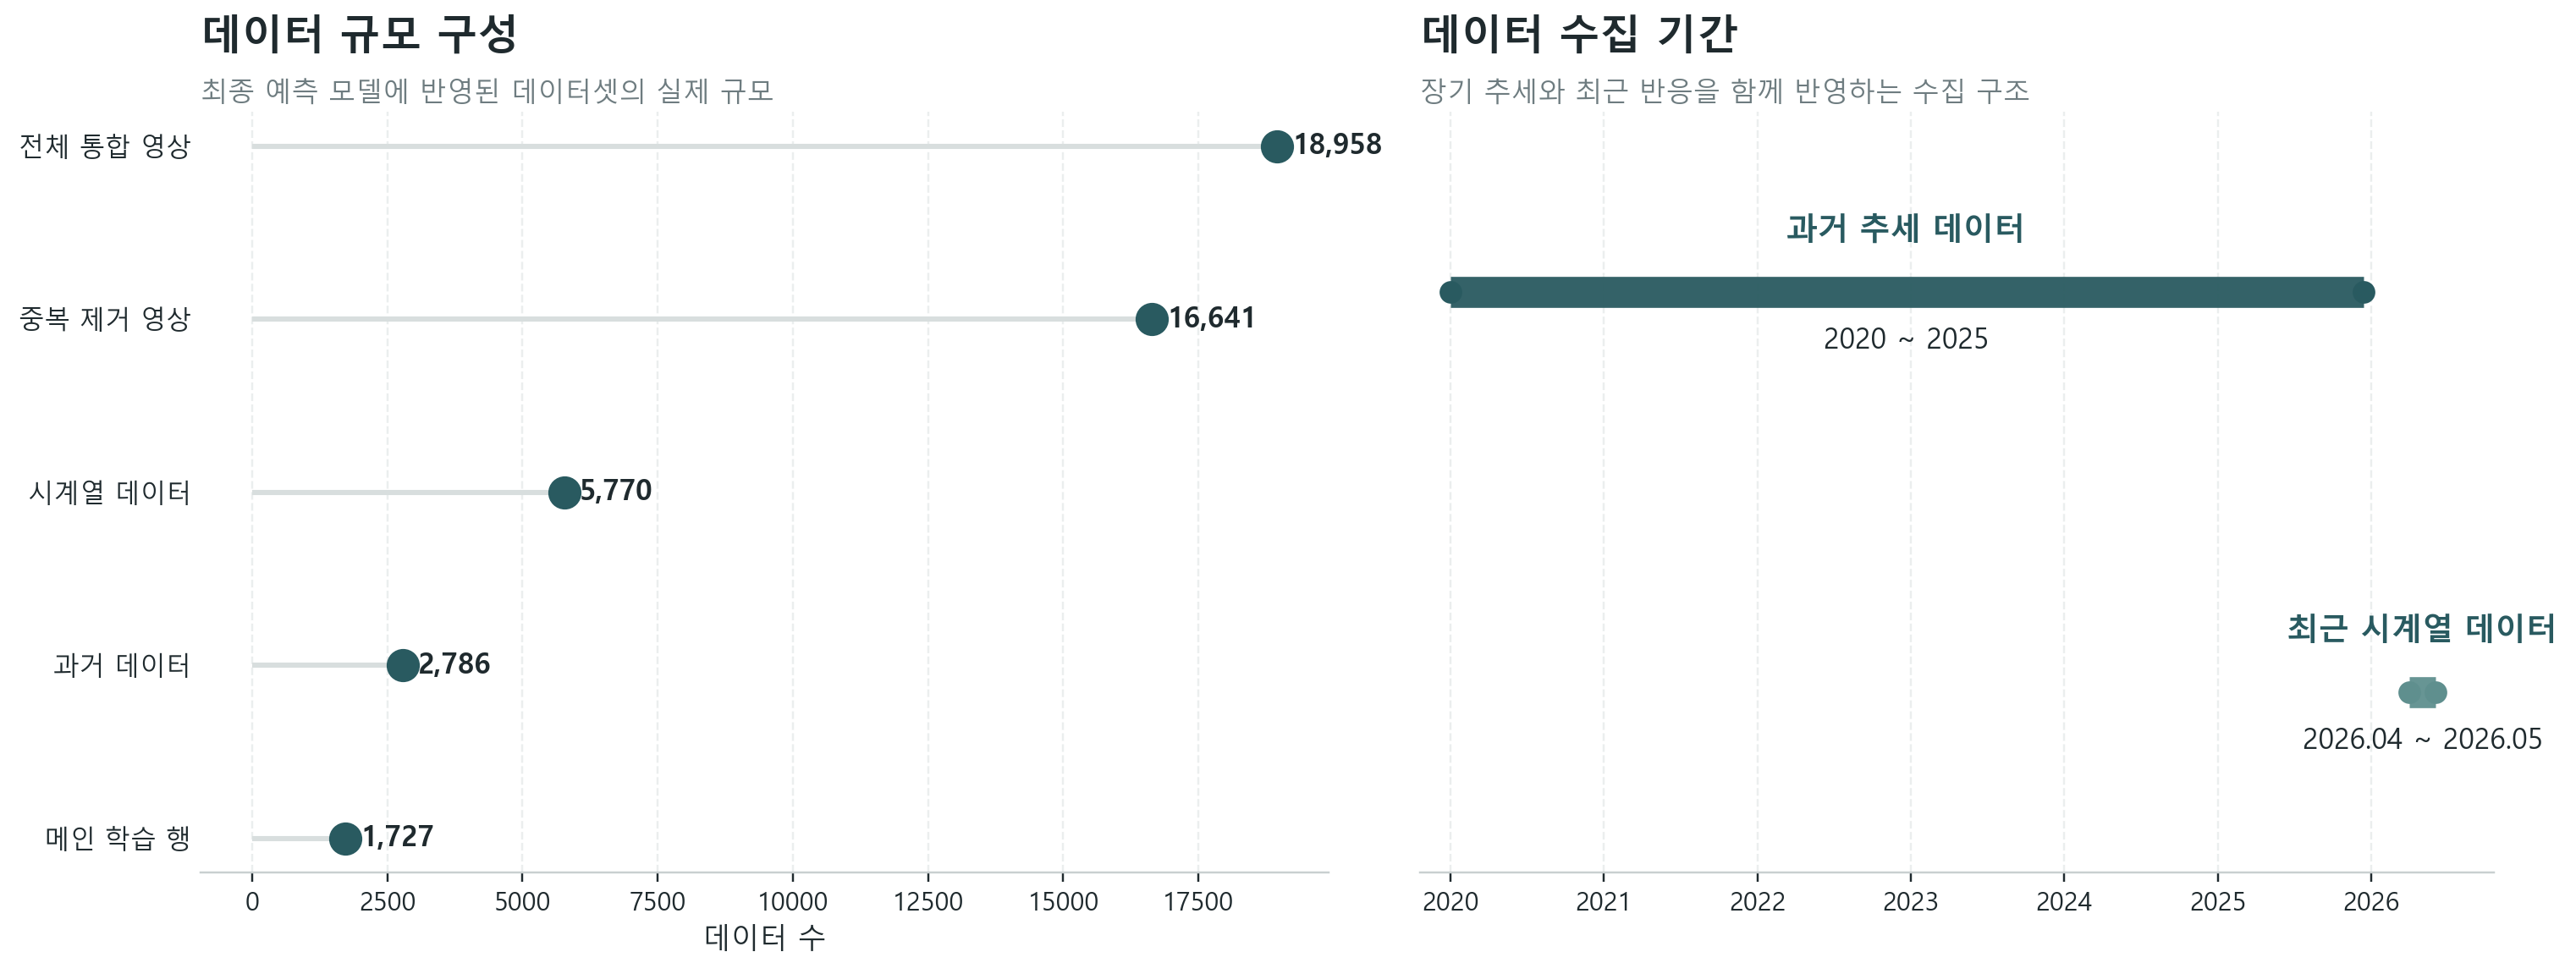

In [3]:
        pv.main()
        display(Image(filename=str(FIG_DIR / 'figure_02_data_landscape.png')))
        


        ## 2. 데이터 정리 및 변수 구성

        서로 다른 형태의 수집 데이터를 그대로 학습에 사용할 수 없기 때문에, 다음과 같은 전처리 과정을 수행하였다.

        1. **데이터 통합 및 형식 정리**: 영상 메타데이터, 과거 추세 데이터, 시계열 데이터를 하나의 분석 흐름으로 연결
        2. **중복 제거 및 기준 정렬**: `video_id` 기준 중복 제거, 업로드 시점과 주차 정보 기준 정렬
        3. **시계열 정합성 확보**: `t1`, `t3`, `t6`, `t24`, `h168`, `h336` 를 통해 반응 흐름 유지
        4. **학습용 테이블 구성**: 영상 단위 데이터와 분야-주차 단위 집계 데이터로 재구성
        


In [4]:
        base_variables = pd.DataFrame([
            ['category', '분야 정보', '영상이 속한 유튜브 분야'],
            ['video_id', '식별 정보', '영상 고유 ID'],
            ['channel_id', '식별 정보', '채널 고유 ID'],
            ['title', '메타데이터', '영상 제목'],
            ['description', '메타데이터', '영상 설명'],
            ['tags', '메타데이터', '영상 태그'],
            ['published_at', '시간 정보', '영상 업로드 시점'],
            ['year_week', '시간 정보', '주차 단위 집계 기준'],
            ['view_count', '기본 반응', '조회수'],
            ['like_count', '기본 반응', '좋아요 수'],
            ['comment_count', '기본 반응', '댓글 수'],
            ['latest_view_count', '최신 반응', '최신 수집 시점 조회수'],
            ['latest_like_count', '최신 반응', '최신 수집 시점 좋아요 수'],
            ['latest_comment_count', '최신 반응', '최신 수집 시점 댓글 수'],
            ['t1_views ~ t24_views', '초기 시계열', '1h, 3h, 6h, 24h 시점별 조회수'],
            ['t1_likes ~ t24_likes', '초기 시계열', '1h, 3h, 6h, 24h 시점별 좋아요 수'],
            ['t1_comments ~ t24_comments', '초기 시계열', '1h, 3h, 6h, 24h 시점별 댓글 수'],
        ], columns=['변수명', '변수 그룹', '설명'])

        derived_variables = pd.DataFrame([
            ['virality_proxy', '성과 파생', '조회수·좋아요·댓글을 결합한 종합 성과 점수'],
            ['growth_views_1_3', '시계열 파생', '1h→3h 구간 조회수 증가량'],
            ['growth_views_3_6', '시계열 파생', '3h→6h 구간 조회수 증가량'],
            ['growth_views_6_24', '시계열 파생', '6h→24h 구간 조회수 증가량'],
            ['t1_engagement_rate ~ t24_engagement_rate', '시계열 파생', '시점별 참여율'],
            ['avg_virality', '집계 변수', '분야-주차 단위 평균 성과'],
            ['video_count', '집계 변수', '분야-주차 단위 영상 수'],
            ['unique_channels', '집계 변수', '분야-주차 단위 고유 채널 수'],
            ['competition_score', '파생 변수', '분야 내 경쟁 강도'],
            ['opportunity_score', '파생 변수', '상대적 성장 기회 점수'],
            ['momentum_ratio', '파생 변수', '최근 반응 대비 추세 가속도'],
            ['trend_delta_1', '추세 변수', '직전 주 대비 변화량'],
            ['trend_delta_2', '추세 변수', '2주 전 대비 변화량'],
            ['rolling_4week_mean', '추세 변수', '최근 4주 평균 추세'],
            ['stability_score', '추세 변수', '성과 변동성의 안정성 지표'],
            ['timeseries_signal_strength', '최종 신호', '시계열 기반 상승 신호 강도'],
        ], columns=['변수명', '변수 그룹', '설명'])

        display(Markdown('### 기본 변수'))
        display(base_variables)
        display(Markdown('### 파생 변수'))
        display(derived_variables)
        


### 기본 변수

,변수명,변수 그룹,설명
0,category,분야 정보,영상이 속한 유튜브 분야
1,video_id,식별 정보,영상 고유 ID
2,channel_id,식별 정보,채널 고유 ID
3,title,메타데이터,영상 제목
4,description,메타데이터,영상 설명
5,tags,메타데이터,영상 태그
6,published_at,시간 정보,영상 업로드 시점
7,year_week,시간 정보,주차 단위 집계 기준
8,view_count,기본 반응,조회수
9,like_count,기본 반응,좋아요 수


### 파생 변수

,변수명,변수 그룹,설명
0,virality_proxy,성과 파생,조회수·좋아요·댓글을 결합한 종합 성과 점수
1,growth_views_1_3,시계열 파생,1h→3h 구간 조회수 증가량
2,growth_views_3_6,시계열 파생,3h→6h 구간 조회수 증가량
3,growth_views_6_24,시계열 파생,6h→24h 구간 조회수 증가량
4,t1_engagement_rate ~ t24_engagement_rate,시계열 파생,시점별 참여율
5,avg_virality,집계 변수,분야-주차 단위 평균 성과
6,video_count,집계 변수,분야-주차 단위 영상 수
7,unique_channels,집계 변수,분야-주차 단위 고유 채널 수
8,competition_score,파생 변수,분야 내 경쟁 강도
9,opportunity_score,파생 변수,상대적 성장 기회 점수


        ## 3. 탐색적 데이터 분석(EDA)

        본 프로젝트에서는 단순 개수 비교보다 **시간에 따른 추세**, **초기 반응 프로파일**, **분야별 상대적 변화 패턴** 을 확인하는 것이 중요하다.
        


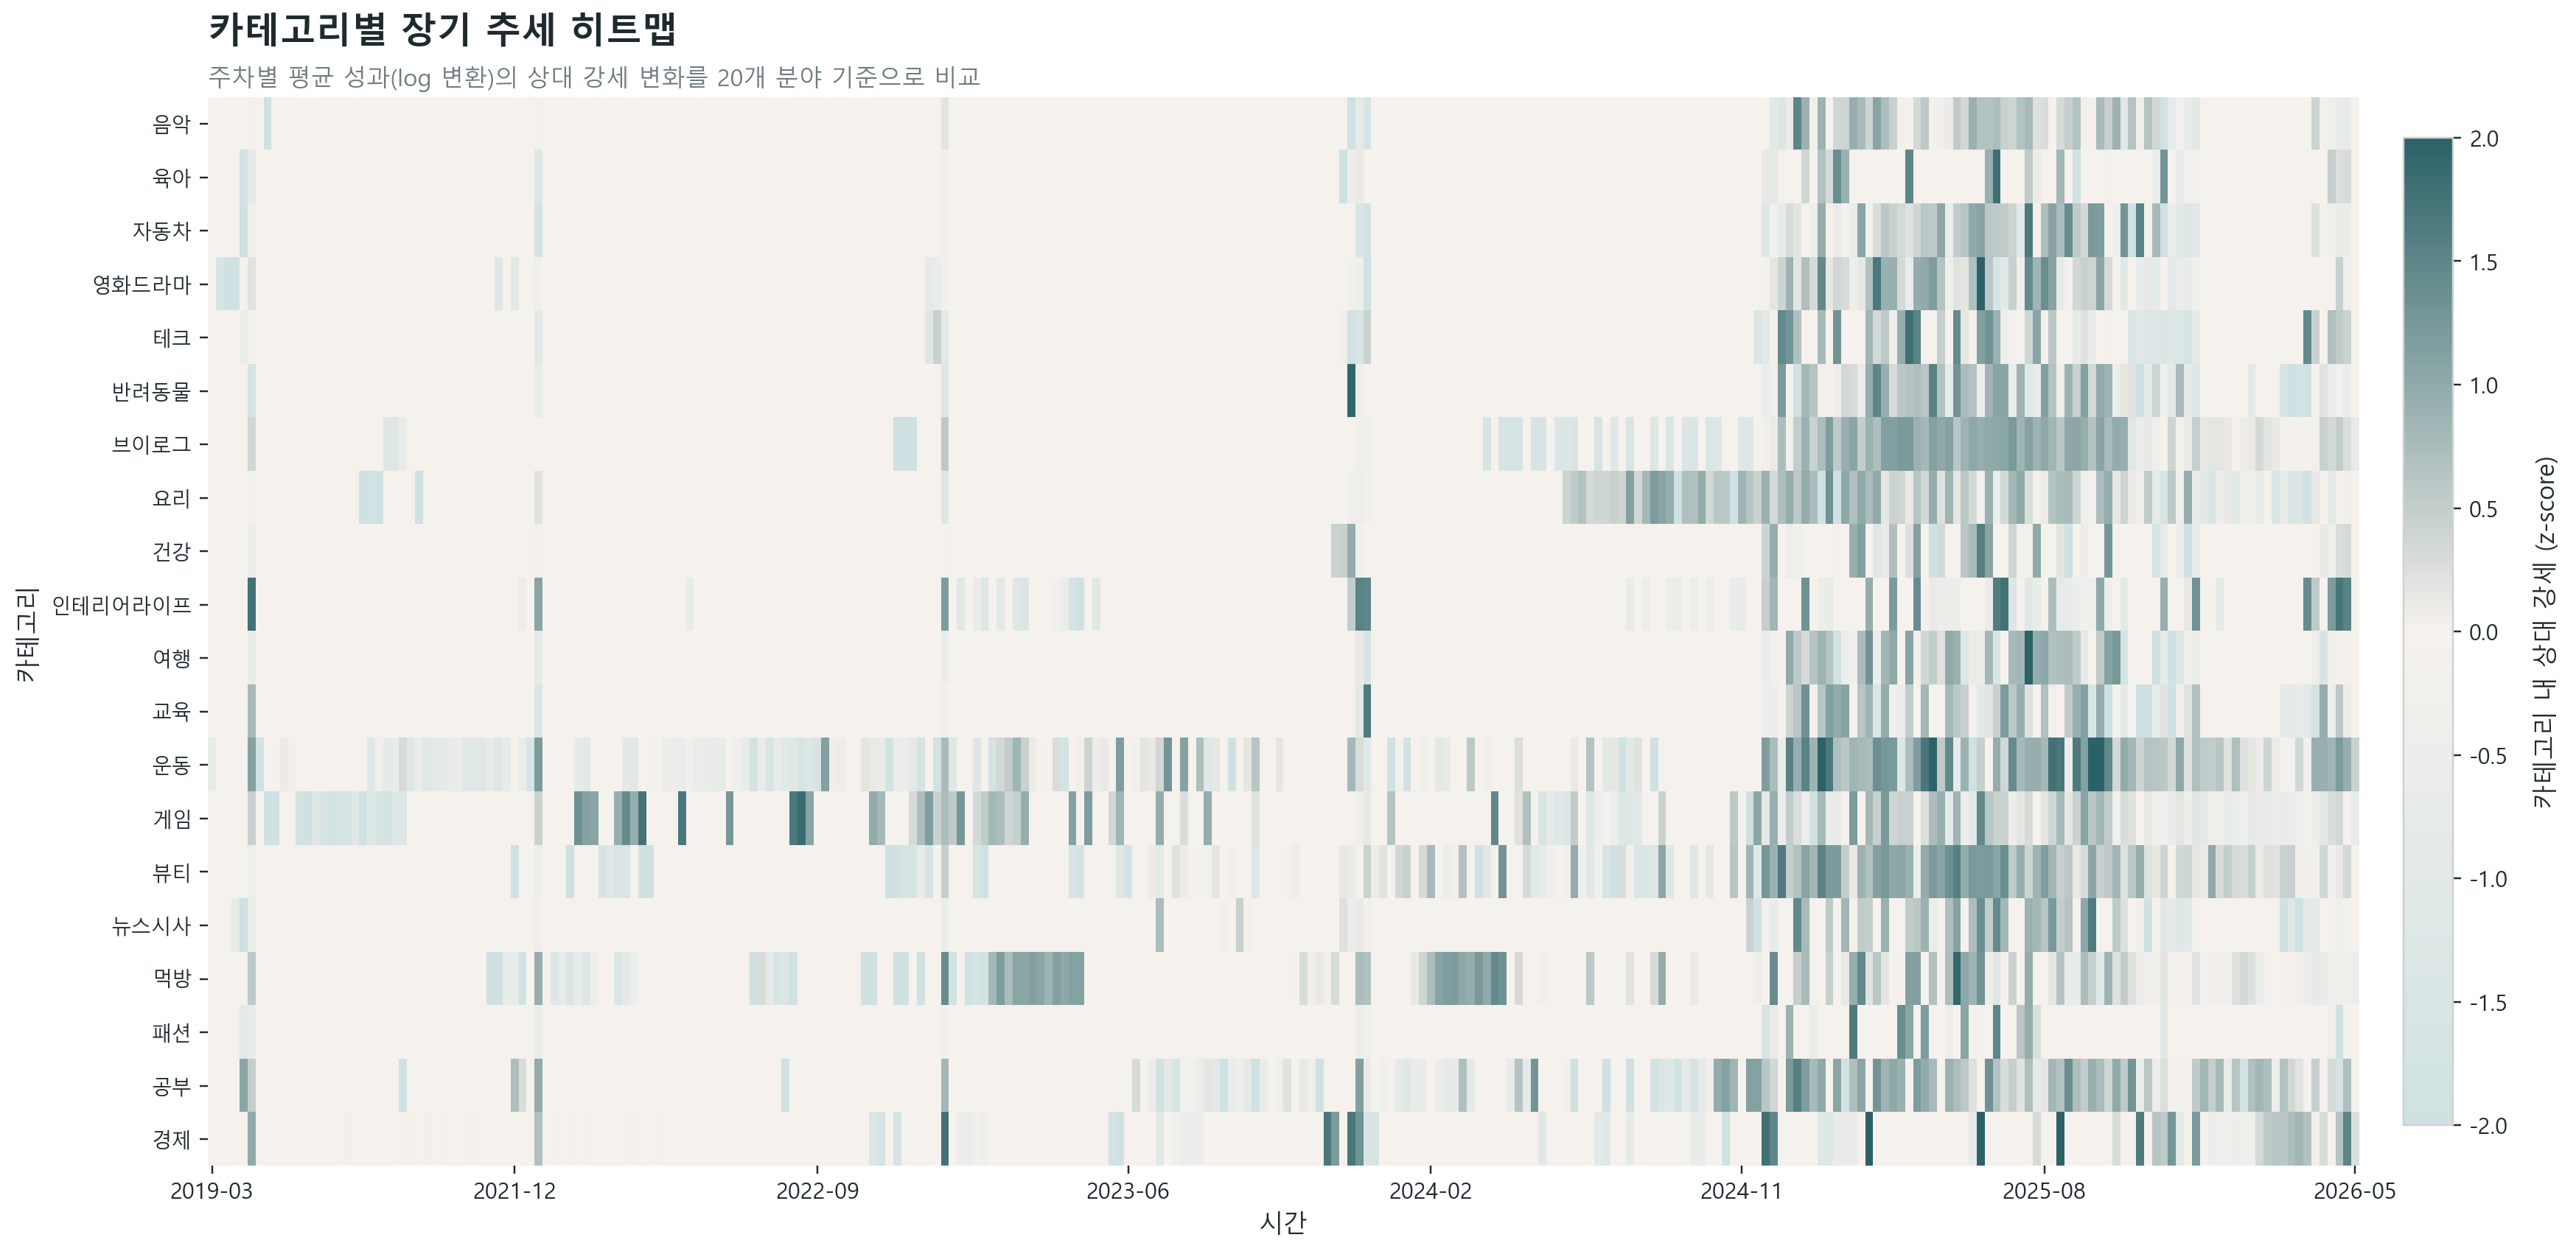

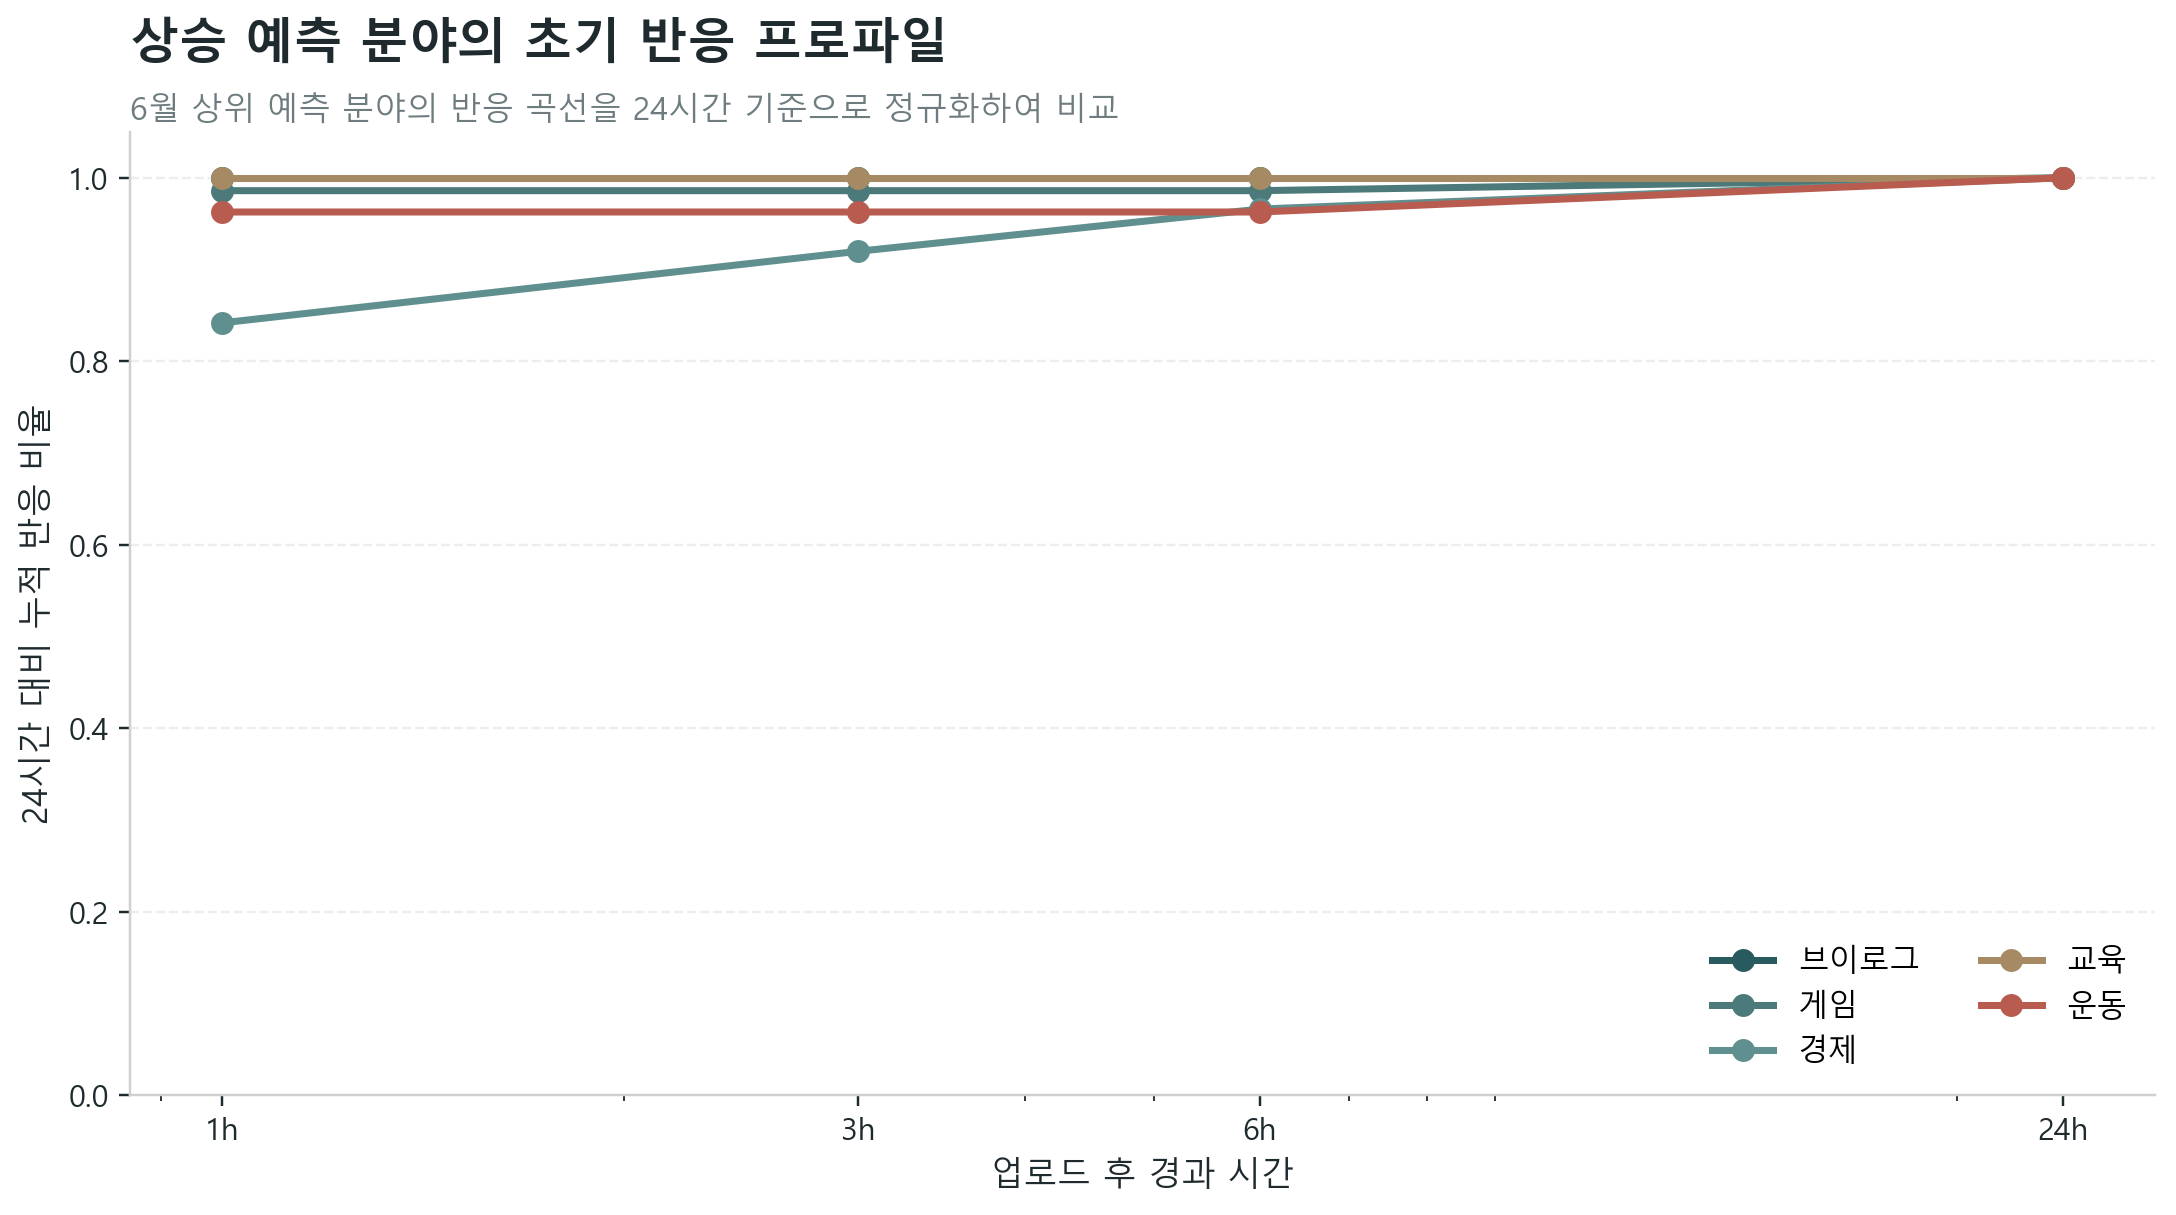

In [5]:
        display(Image(filename=str(FIG_DIR / 'figure_03_category_trend_heatmap.png')))
        display(Image(filename=str(FIG_DIR / 'figure_03_early_response_profiles.png')))
        


        위 시각화는 다음 사실을 보여준다.

        - 카테고리별 장기 추세는 동일하지 않으며, 특정 시점에 상대적 강세가 다르게 이동한다.
        - 상위 예측 분야는 초기 24시간 동안 유사한 반응 패턴을 보이기도 하지만, 증가 속도와 안정성은 서로 다르다.
        - 따라서 본 연구에서는 단순 누적 성과보다 **시계열 기반 반응 흐름** 을 함께 고려할 필요가 있다.
        


        ## 4. 모델 수립 및 비교 실험

        본 프로젝트의 핵심 문제는 절대 조회수 예측이 아니라, **어떤 분야가 상승할 가능성이 높은가** 를 판단하는 것이다.

        따라서 최종 문제 정의는 다음과 같다.

        - 입력: 과거 추세 + 최근 시계열 반응
        - 출력: 6월 / Q3 / Q4 상승 가능성
        - 학습 형태: **분류 및 랭킹**

        또한 논문형 비교를 위해 단일 모델과 얕은 앙상블 모델을 함께 비교하였다.
        


In [6]:
        pme.main()

        monthly_comparison = pd.read_csv(PAPER_MONTHLY_COMPARISON_PATH)
        monthly_comparison_summary = json.loads(PAPER_MONTHLY_SUMMARY_PATH.read_text(encoding='utf-8-sig'))
        monthly_ranking = pd.read_csv(PAPER_MONTHLY_RANKING_PATH)
        monthly_ranking_summary = json.loads(PAPER_MONTHLY_RANKING_SUMMARY_PATH.read_text(encoding='utf-8-sig'))

        display(Markdown('### 월간 분류 모델 비교'))
        display(monthly_comparison)
        display(monthly_comparison_summary)

        display(Markdown('### 월간 랭킹 모델 비교'))
        display(monthly_ranking)
        display(monthly_ranking_summary)
        


                         model   family  decision_threshold  test_rows                      holdout_weeks  accuracy  balanced_accuracy       f1  precision   recall  roc_auc                                                                      members
HistGradientBoostingClassifier     base                0.45         40 2026-12, 2026-13, 2026-14, 2026-15     0.850           0.784946 0.903226   0.903226 0.903226 0.845878                                                                          NaN
               Ensemble_HGB_ET ensemble                0.41         40 2026-12, 2026-13, 2026-14, 2026-15     0.850           0.784946 0.903226   0.903226 0.903226 0.835125                         HistGradientBoostingClassifier, ExtraTreesClassifier
                Ensemble_RF_ET ensemble                0.32         40 2026-12, 2026-13, 2026-14, 2026-15     0.825           0.689964 0.892308   0.852941 0.935484 0.767025                                 RandomForestClassifier, ExtraTreesClassifier


### 월간 분류 모델 비교

,model,family,decision_threshold,test_rows,holdout_weeks,accuracy,balanced_accuracy,f1,precision,recall,roc_auc,members
0,HistGradientBoostingClassifier,base,0.45,40,"2026-12, 2026-13, 2026-14, 2026-15",0.850,0.784946,0.903226,0.903226,0.903226,0.845878,NaN
1,Ensemble_HGB_ET,ensemble,0.41,40,"2026-12, 2026-13, 2026-14, 2026-15",0.850,0.784946,0.903226,0.903226,0.903226,0.835125,"HistGradientBoostingClassifier, ExtraTreesClas..."
2,Ensemble_RF_ET,ensemble,0.32,40,"2026-12, 2026-13, 2026-14, 2026-15",0.825,0.689964,0.892308,0.852941,0.935484,0.767025,"RandomForestClassifier, ExtraTreesClassifier"
3,RandomForestClassifier,base,0.31,40,"2026-12, 2026-13, 2026-14, 2026-15",0.825,0.689964,0.892308,0.852941,0.935484,0.752688,NaN
4,GradientBoostingClassifier,base,0.32,40,"2026-12, 2026-13, 2026-14, 2026-15",0.825,0.729391,0.888889,0.875000,0.903226,0.827957,NaN
5,Ensemble_HGB_RF,ensemble,0.31,40,"2026-12, 2026-13, 2026-14, 2026-15",0.825,0.729391,0.888889,0.875000,0.903226,0.820789,"HistGradientBoostingClassifier, RandomForestCl..."
6,Ensemble_HGB_RF_ET,ensemble,0.31,40,"2026-12, 2026-13, 2026-14, 2026-15",0.825,0.729391,0.888889,0.875000,0.903226,0.820789,"HistGradientBoostingClassifier, RandomForestCl..."
7,ExtraTreesClassifier,base,0.35,40,"2026-12, 2026-13, 2026-14, 2026-15",0.800,0.673835,0.875000,0.848485,0.903226,0.784946,NaN
8,LogisticRegression,base,0.57,40,"2026-12, 2026-13, 2026-14, 2026-15",0.600,0.702509,0.666667,0.941176,0.516129,0.731183,NaN


{'generated_at': '2026-05-18T17:45:37',
 'rise_threshold_ratio': 1.05,
 'validation_fold_count': 3,
 'best_model': 'HistGradientBoostingClassifier',
 'best_family': 'base',
 'best_metrics': {'accuracy': 0.85,
  'balanced_accuracy': 0.7849462365591398,
  'f1': 0.9032258064516129,
  'precision': 0.9032258064516129,
  'recall': 0.9032258064516129,
  'roc_auc': 0.8458781362007168,
  'decision_threshold': 0.4500000000000002}}

### 월간 랭킹 모델 비교

,ranking_model,members,weights,cv_ndcg5,cv_precision_at_5,test_ndcg5,test_precision_at_5
0,HGB_RF_ET_0.5_0.3_0.2,"HGB, RF, ET","HGB:0.5, RF:0.3, ET:0.2",0.899855,0.733333,0.973528,0.95
1,HGB_RF_0.6_0.4,"HGB, RF","HGB:0.6, RF:0.4",0.900211,0.733333,0.972853,0.95
2,RF_ET_0.5_0.5,"RF, ET","RF:0.5, ET:0.5",0.853343,0.733333,0.964291,0.85
3,RF,RF,RF:1.0,0.881736,0.733333,0.962040,0.85
4,HGB,HGB,HGB:1.0,0.882695,0.716667,0.947793,0.95
5,HGB_ET_0.6_0.4,"HGB, ET","HGB:0.6, ET:0.4",0.895813,0.733333,0.947303,0.95
6,ET,ET,ET:1.0,0.885255,0.750000,0.934760,0.85


{'generated_at': '2026-05-18T17:13:35.481446',
 'best_ranking_model': 'HGB_RF_ET_0.5_0.3_0.2',
 'best_metrics': {'cv_ndcg5': 0.8998549357813052,
  'cv_precision_at_5': 0.7333333333333334,
  'test_ndcg5': 0.9735275462939958,
  'test_precision_at_5': 0.95}}

        비교 실험 결과, **6월 상승 여부 분류** 는 `HistGradientBoostingClassifier` 가 가장 안정적이었다.

        - Accuracy: 0.850
        - Balanced Accuracy: 0.785
        - F1: 0.903
        - ROC AUC: 0.846

        반면 **상위 분야 순위화(Top-N)** 는 단일 모델보다 얕은 혼합 랭킹이 더 강했다.

        - 최적 랭킹 모델: `HGB + RF + ET (0.5 / 0.3 / 0.2)`
        - Test NDCG@5: 0.974
        - Test Precision@5: 0.95
        


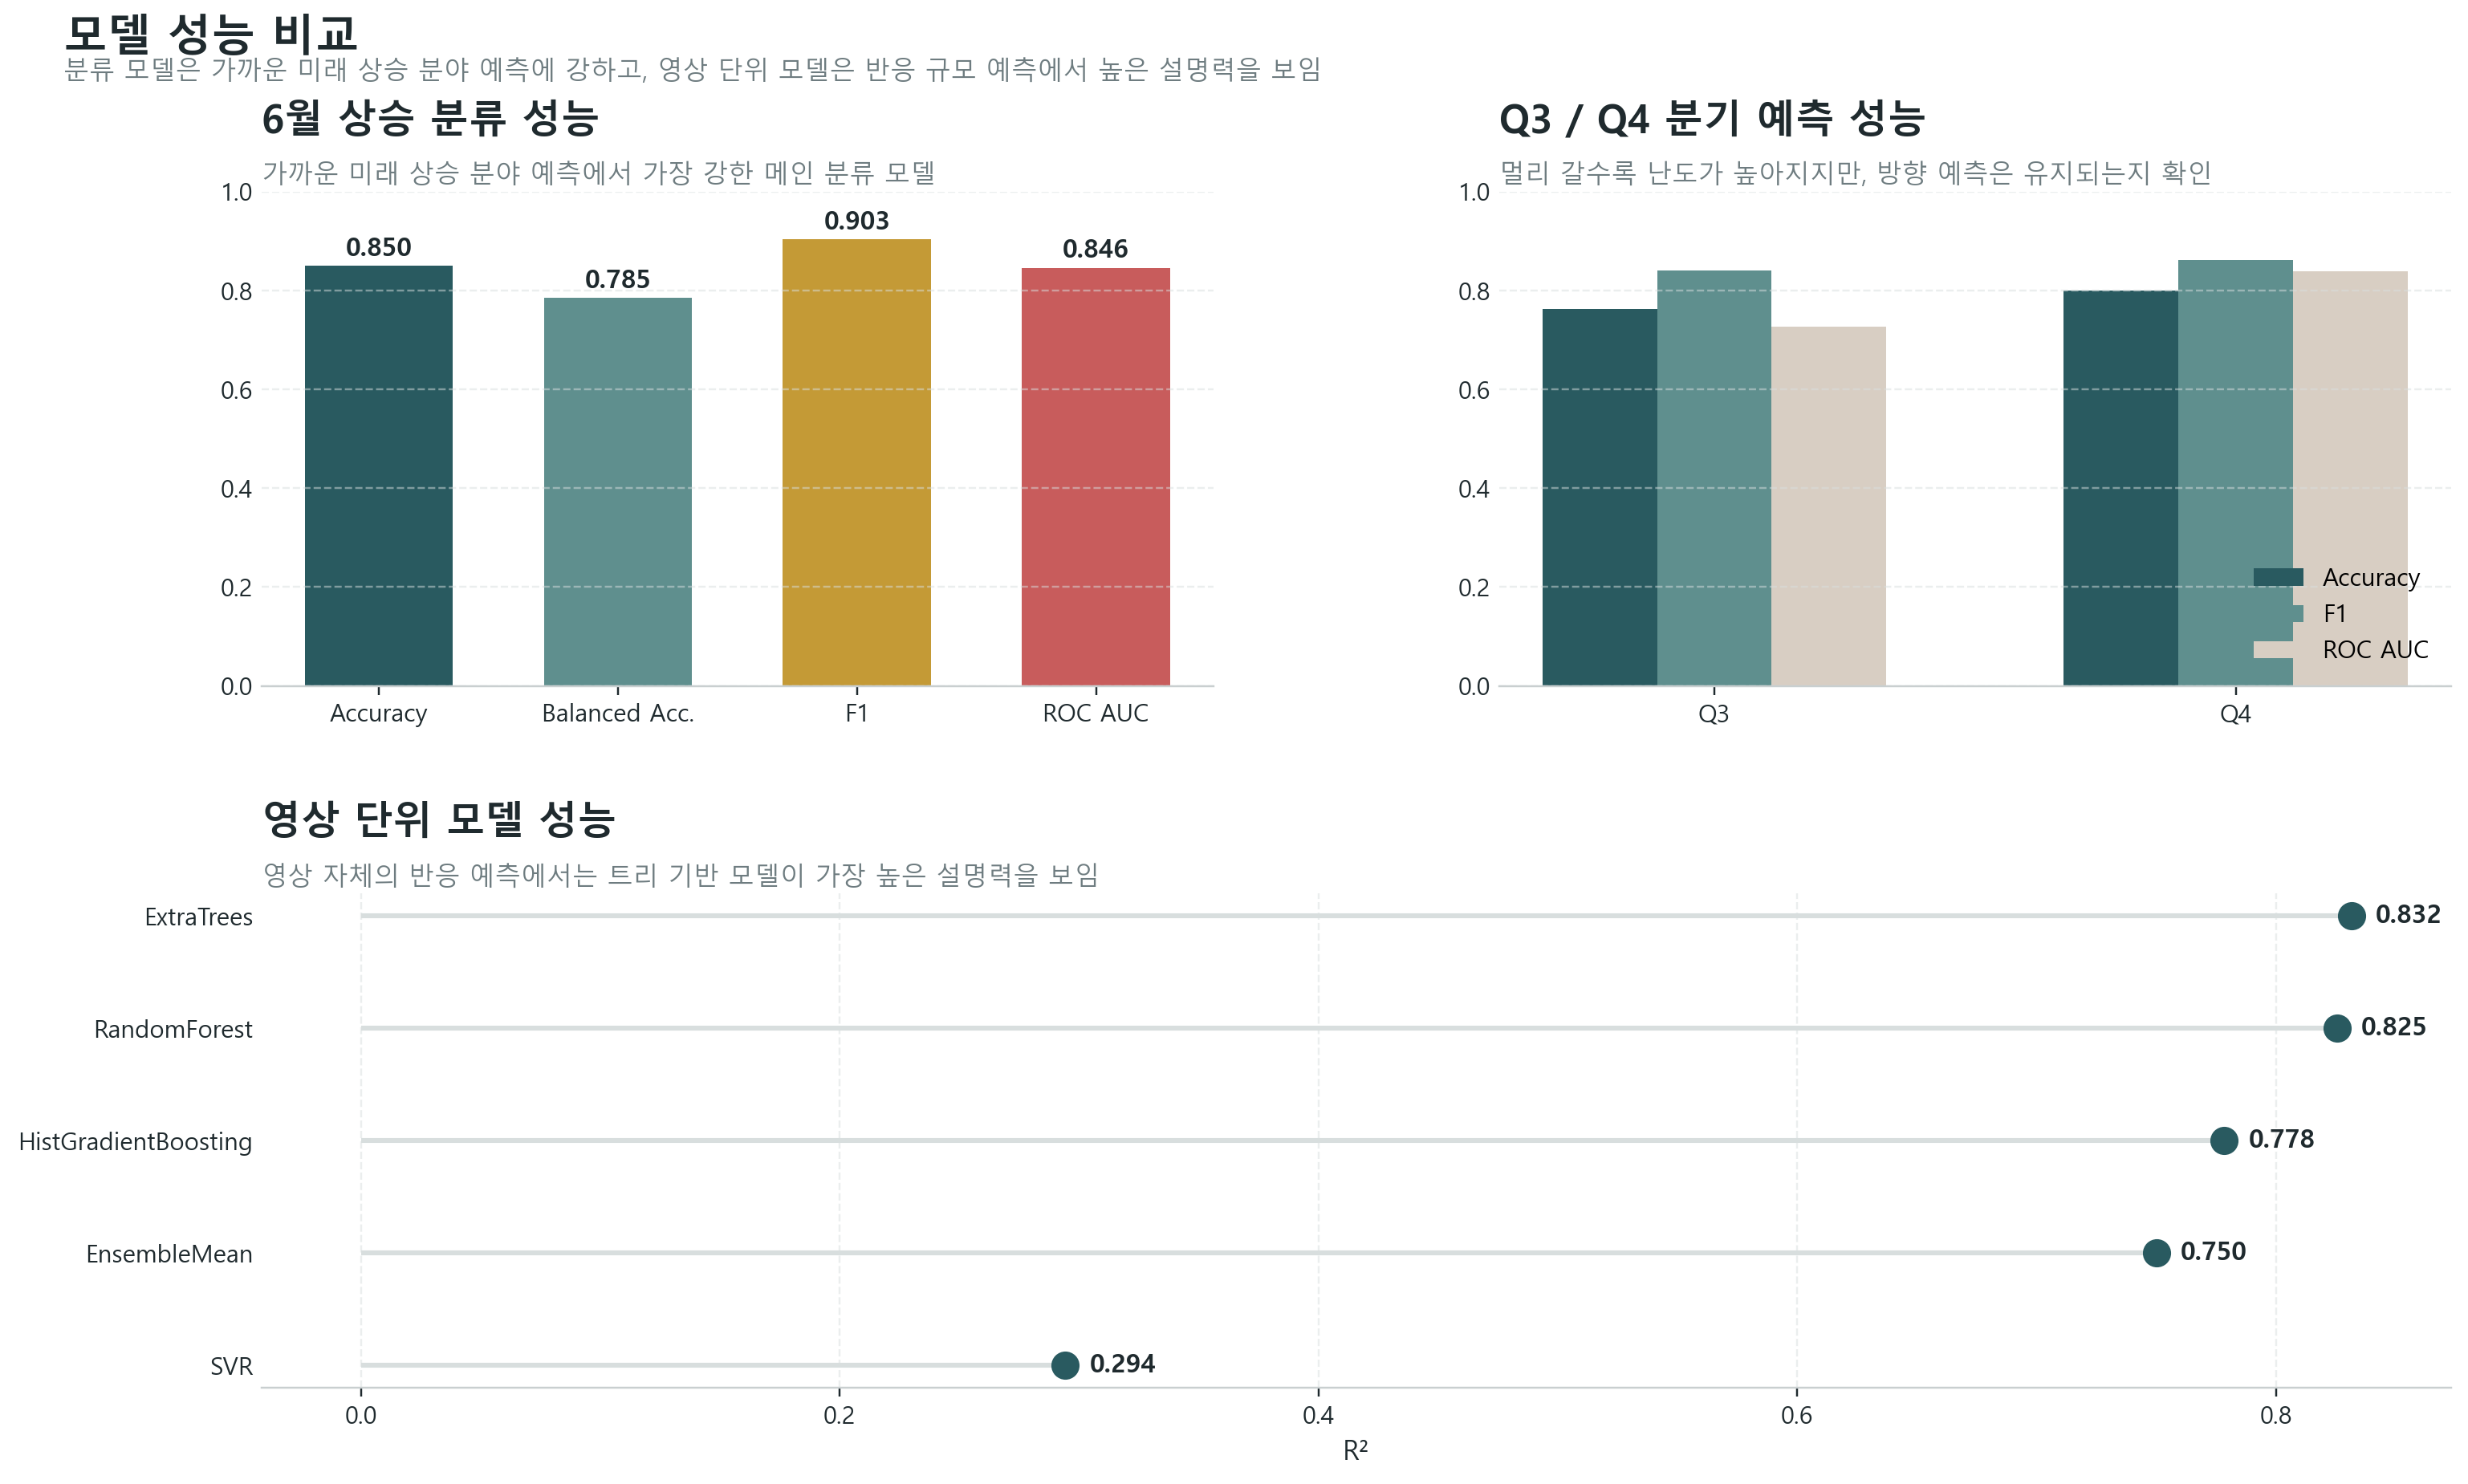

In [7]:
        display(Image(filename=str(FIG_DIR / 'figure_05_model_performance.png')))
        


        ## 5. 최종 예측 결과

        최종 결과는 단순 확률이 아니라 **분류 확률 + 시계열 모멘텀 + 랭킹 점수** 를 결합한 최종 상승 점수로 제시한다.
        


In [8]:
        june_pred = pd.read_csv(direction_summary['outputs']['june_classification'])
        q34_pred = pd.read_csv(direction_summary['outputs']['q34_classification'])
        top_categories = pd.read_csv(direction_summary['outputs']['top_categories'])

        display(Markdown('### 6월 예측 결과 상위 10개'))
        display(june_pred[['category', 'rise_probability', 'ranking_probability', 'momentum_score', 'final_rise_score', 'final_direction']].head(10))

        display(Markdown('### 최종 대표 분야'))
        display(top_categories)
        


### 6월 예측 결과 상위 10개

,category,rise_probability,ranking_probability,momentum_score,final_rise_score,final_direction
0,브이로그,0.967653,0.839255,0.297537,0.887773,rise_expected
1,게임,0.844768,0.746233,1.479261,0.880754,rise_expected
2,경제,0.777525,0.755631,0.387347,0.811408,rise_expected
3,교육,0.774275,0.658062,1.321184,0.772180,rise_expected
4,운동,0.745675,0.706801,0.196562,0.734234,rise_expected
5,뉴스시사,0.739556,0.644163,0.650256,0.717835,rise_expected
6,자동차,0.894788,0.714775,-0.280732,0.675665,rise_expected
7,먹방,0.747791,0.671041,-0.159848,0.649769,rise_expected
8,패션,0.900839,0.645001,-0.003892,0.644499,rise_expected
9,테크,0.808997,0.672731,-0.293668,0.634317,rise_expected


### 최종 대표 분야

,target_period,representative_category,rise_probability,ranking_probability,decision_threshold,momentum_score,final_rise_score,direction
0,2026-06,브이로그,0.967653,0.839255,0.45,0.297537,0.887773,rise_expected
1,2026-Q3,인테리어라이프,0.659453,NaN,0.31,0.232999,0.682093,rise_expected
2,2026-Q4,게임,0.999929,NaN,0.25,1.479261,1.000000,rise_expected


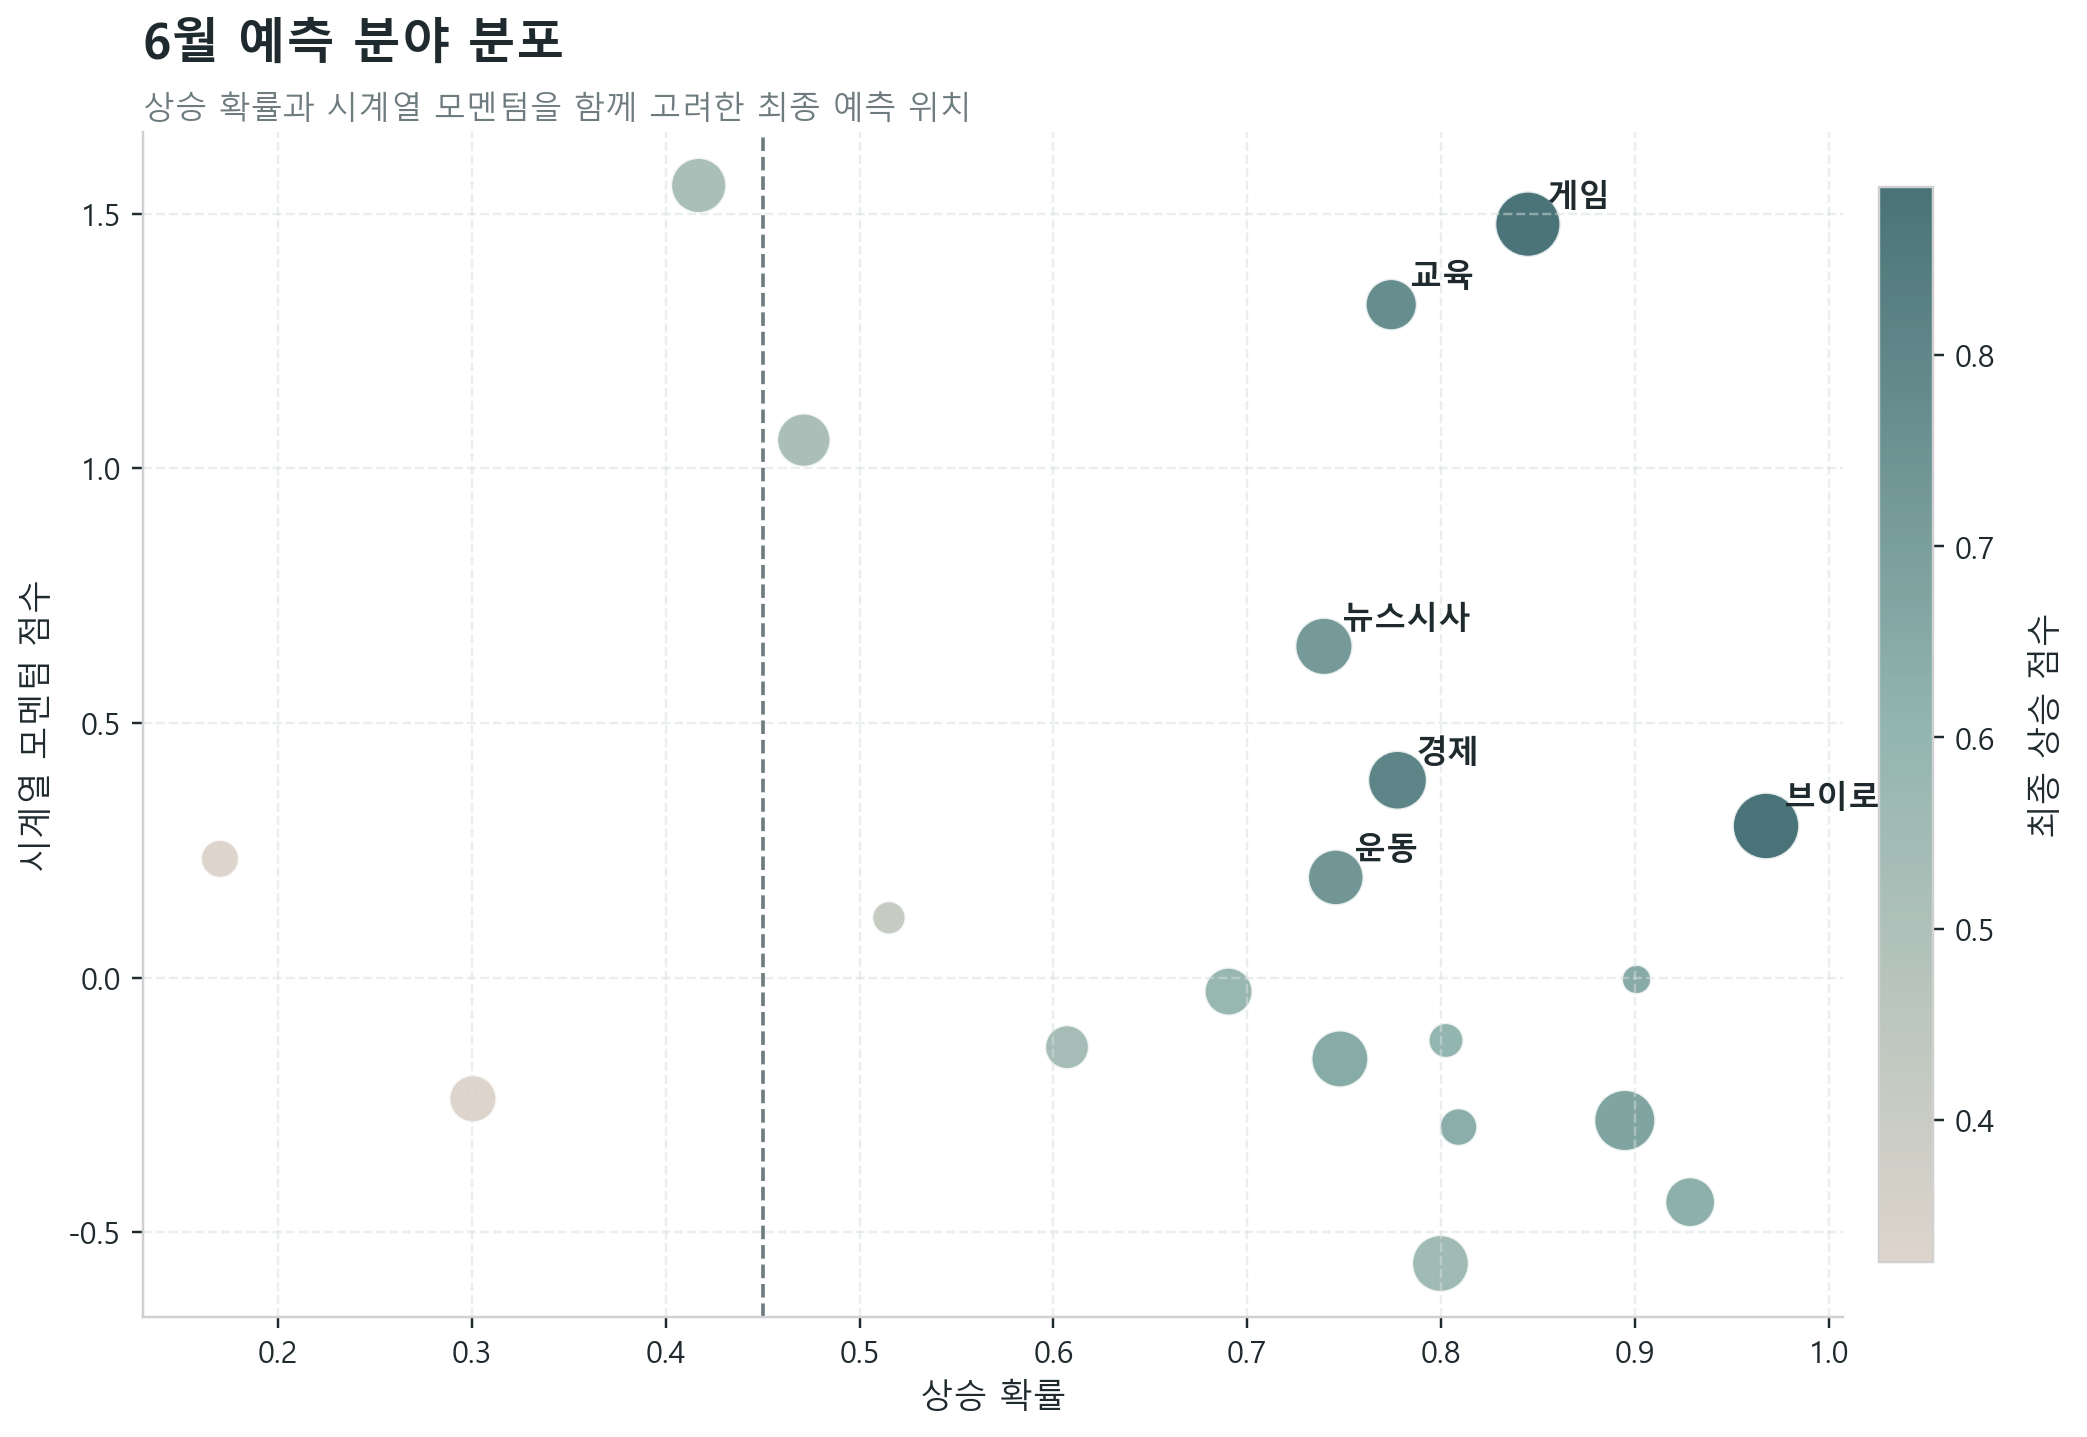

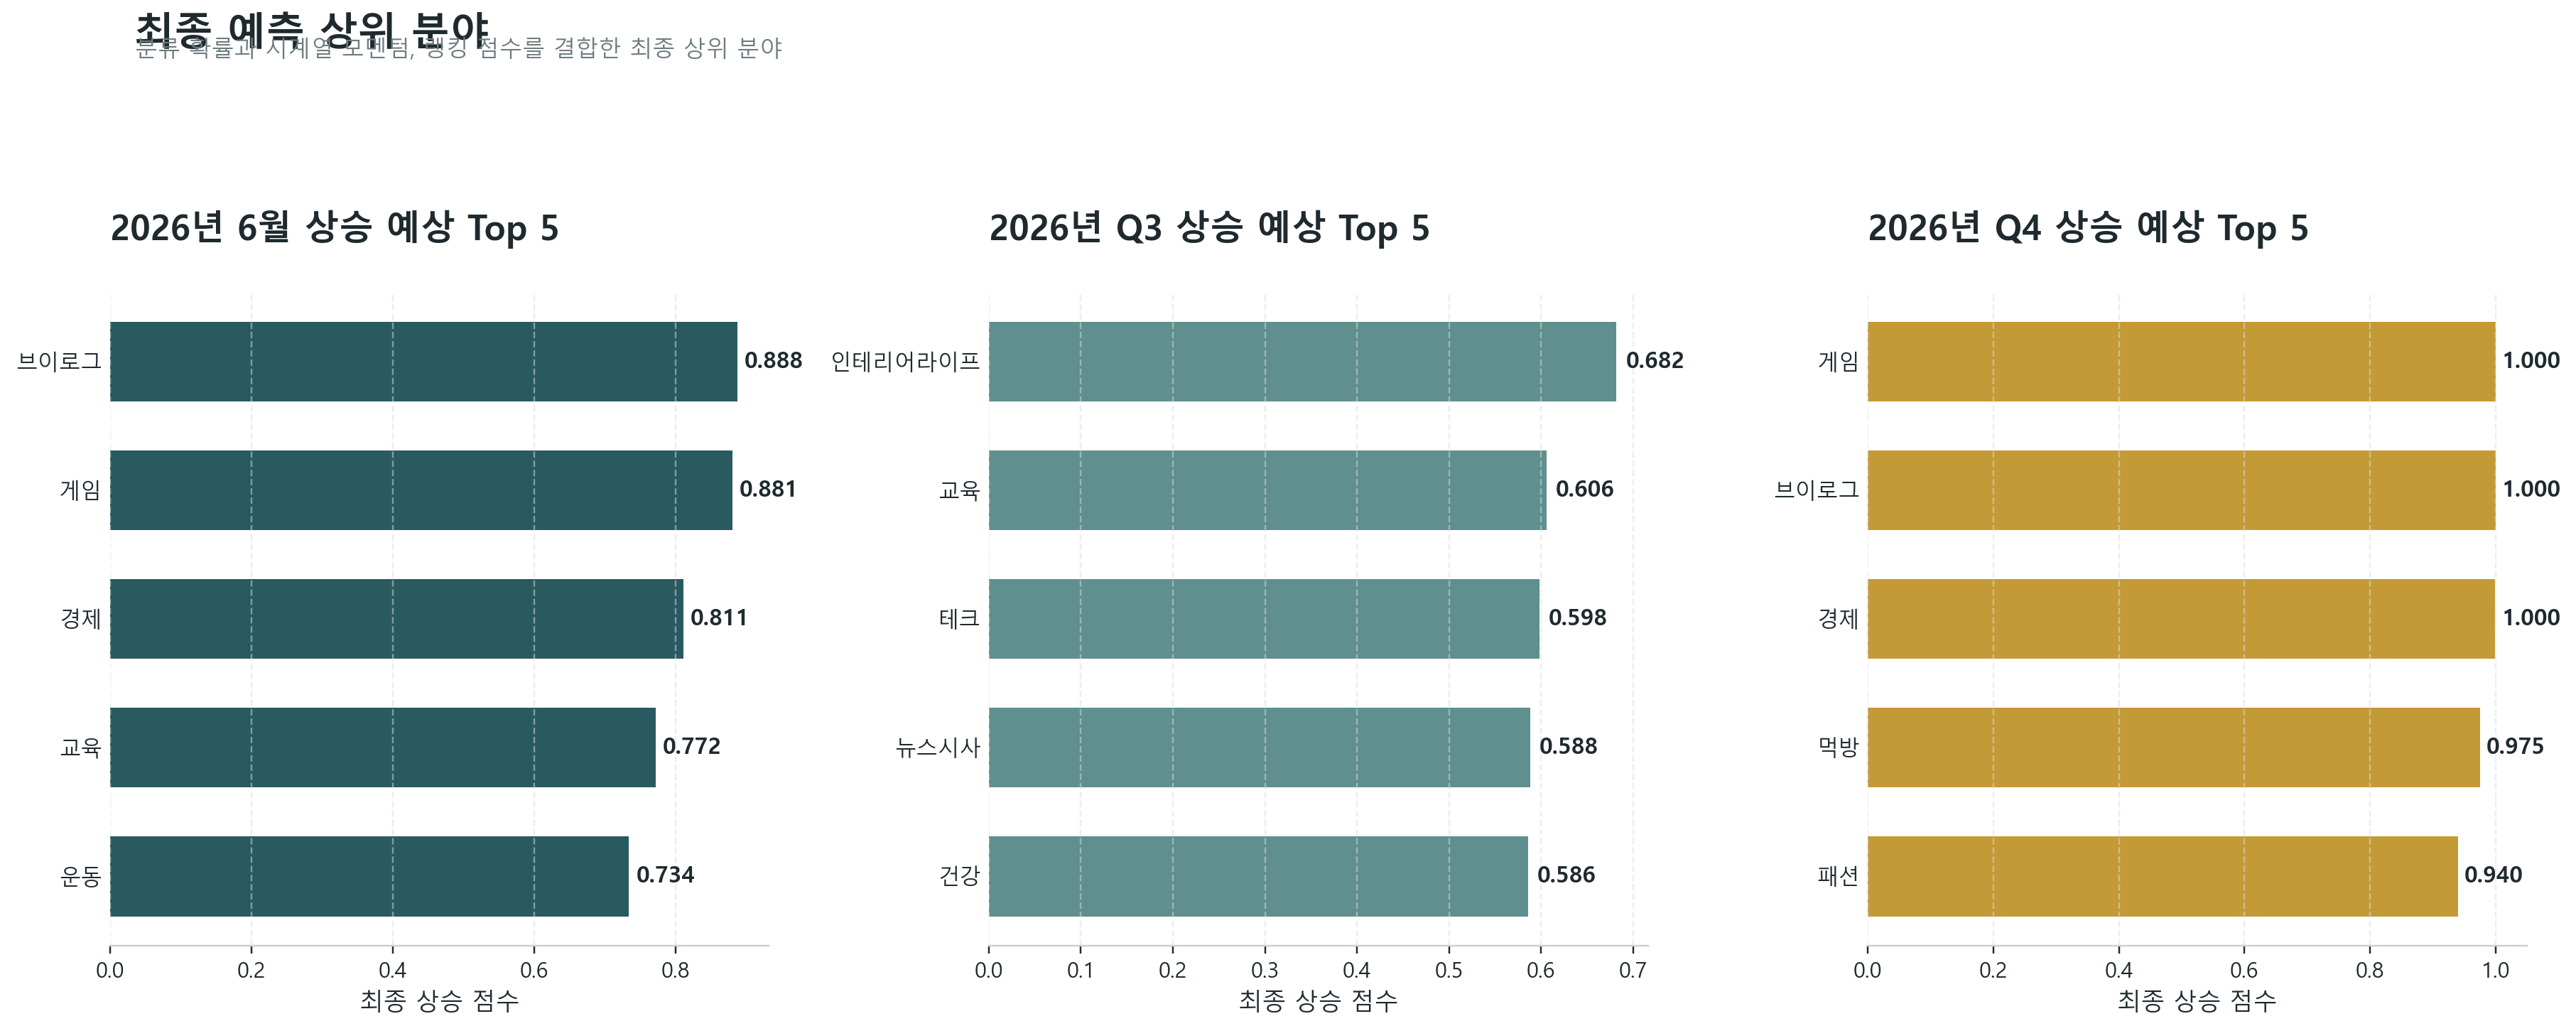

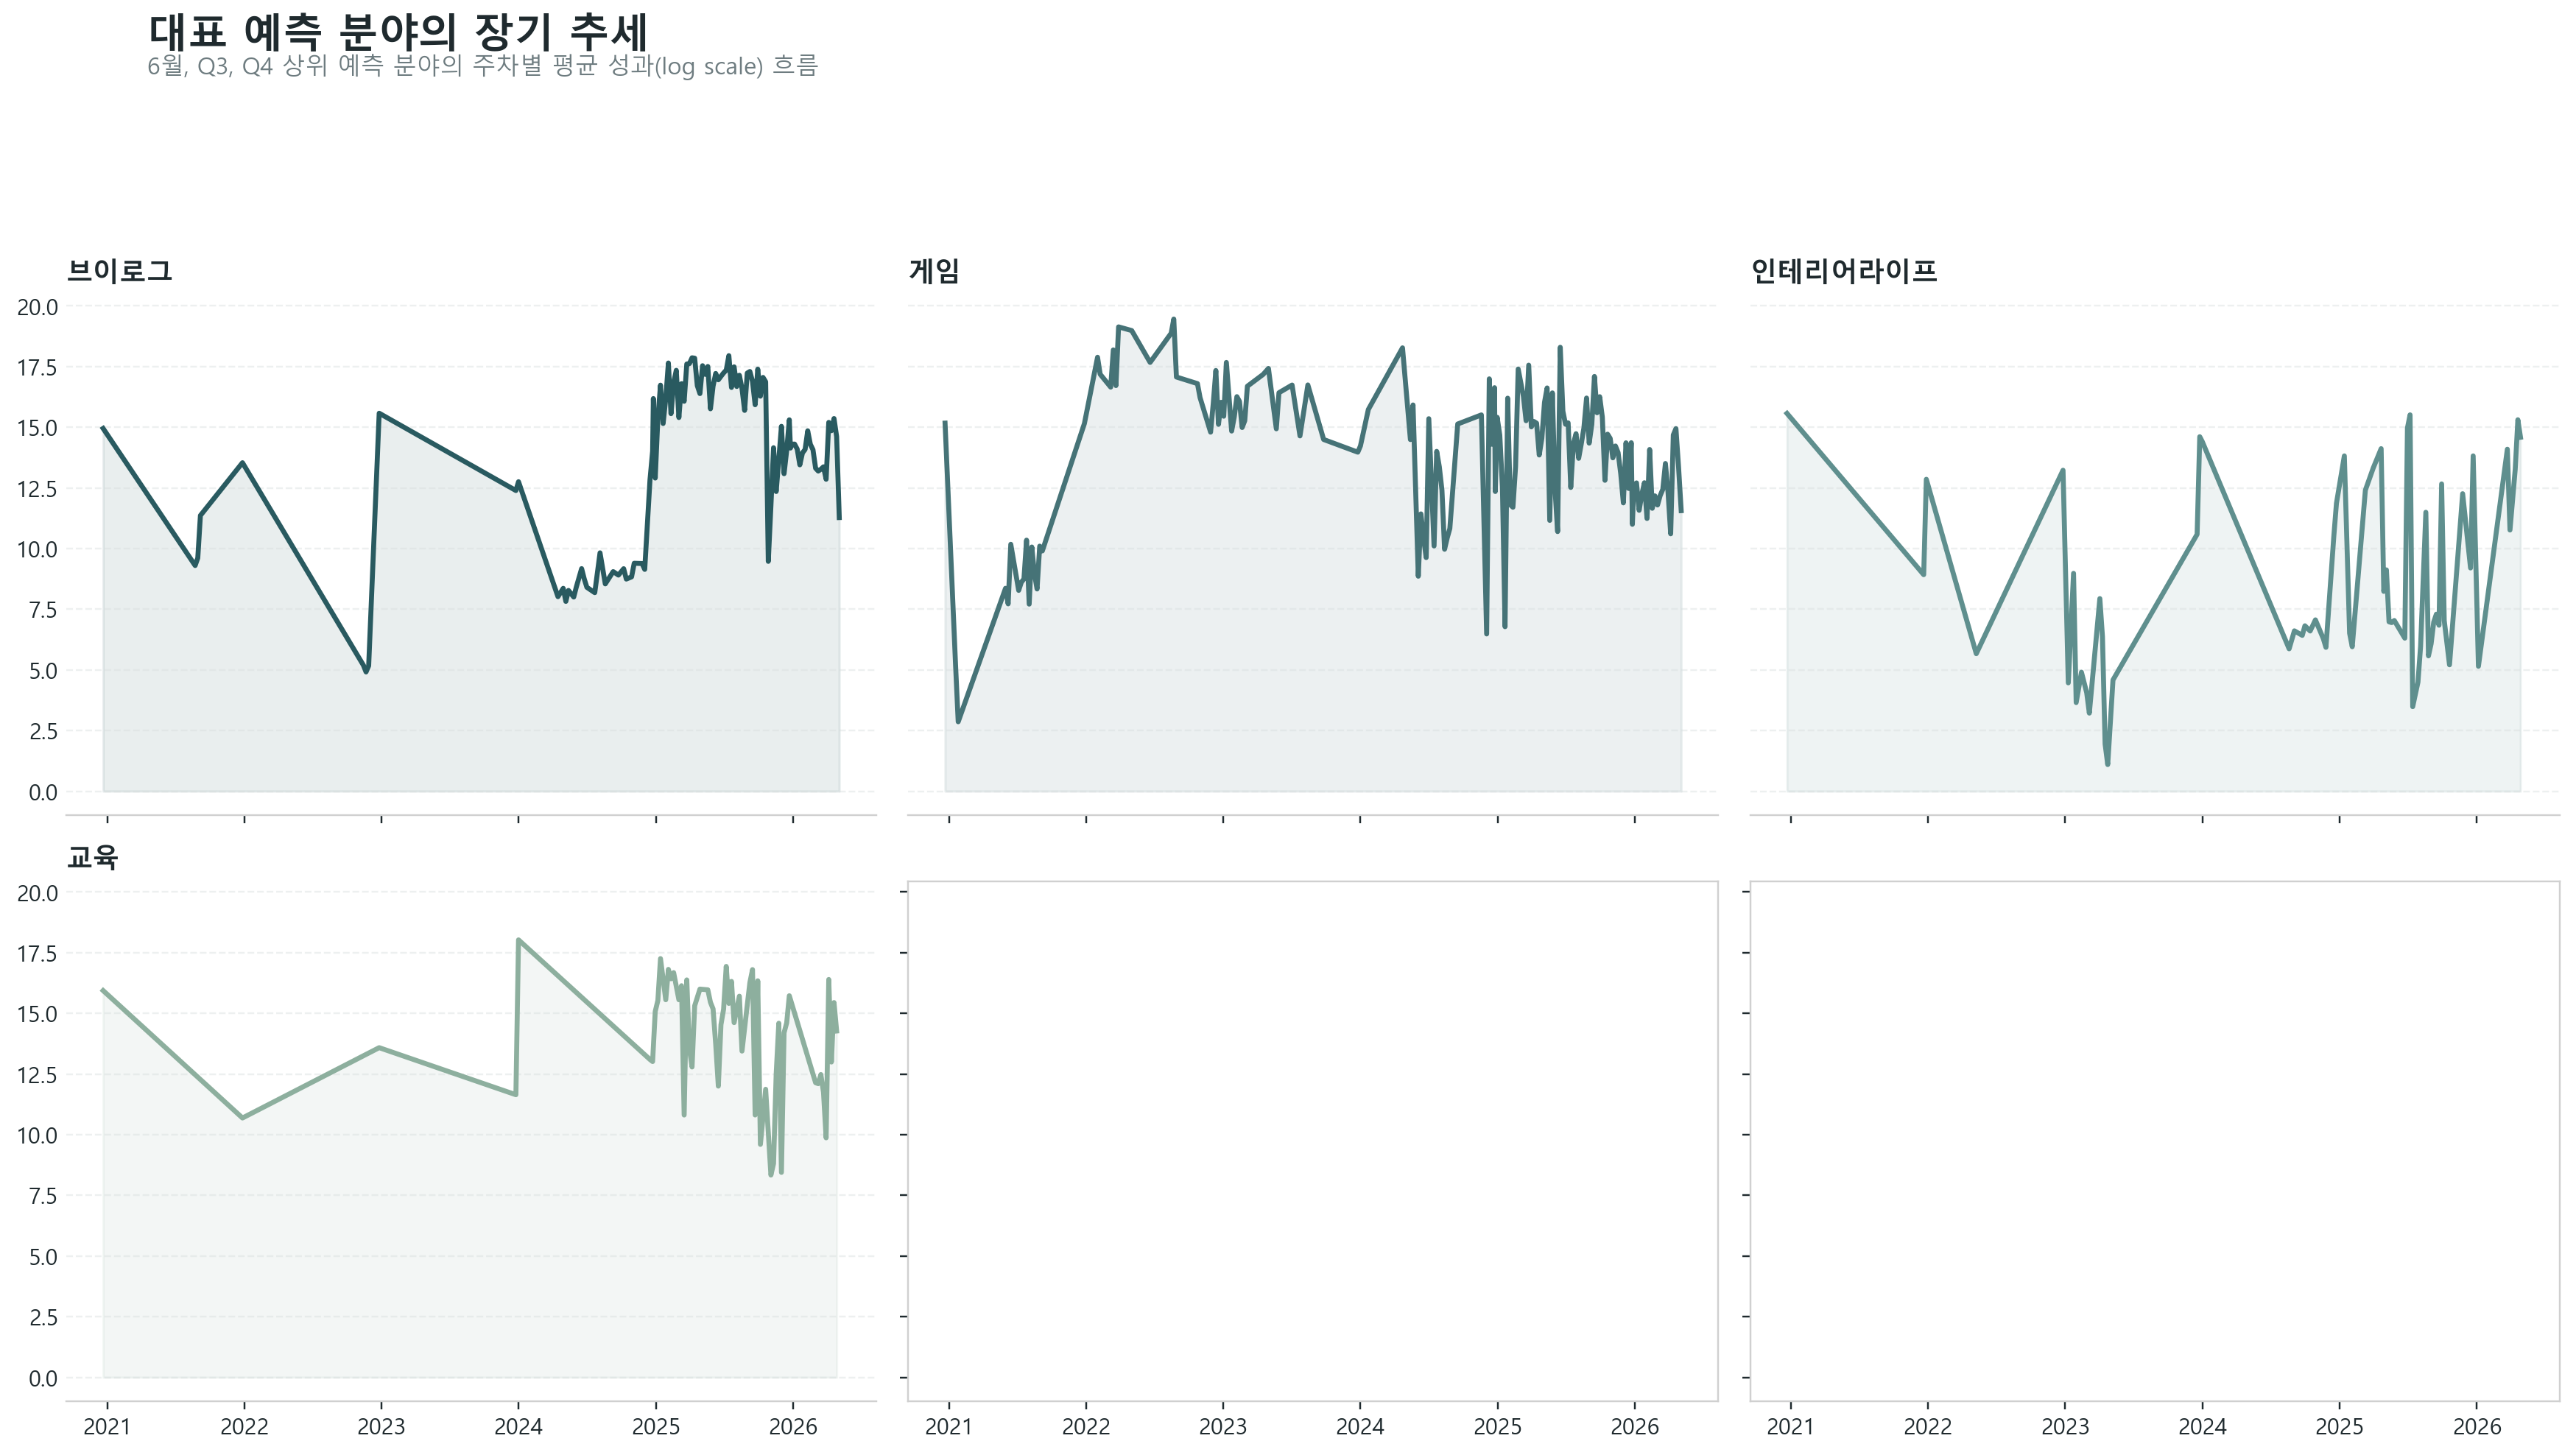

In [9]:
        display(Image(filename=str(FIG_DIR / 'figure_05_prediction_map.png')))
        display(Image(filename=str(FIG_DIR / 'figure_05_top_categories.png')))
        display(Image(filename=str(FIG_DIR / 'figure_05_representative_trajectories.png')))
        
